# RealNVP

A simple example implementation of RealNVP, for the purposes of a tutorial. Not optimized for performance. Written for clarity.

Reference: [Dinh *et al* (2016), "Density estimation using Real NVP", arXiv:1605.08803](https://arxiv.org/abs/1605.08803).

In [ ]:
! pip3 install tensorflow dm-sonnet \
               numpy matplotlib tqdm scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.4/268.4 kB 11.7 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import sonnet as snt

import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.dpi': 150,
})

from tqdm.auto import tqdm

One *affine coupling layer*:

$$
  \begin{aligned}
    y_{1: d} &= x_{1: d} \\
    y_{d+1: D} &= x_{d+1: D} \odot \exp \left[s\left(x_{1: d}\right)\right]+t\left(x_{1: d}\right)
  \end{aligned}
$$

Transforms the input vector $\vec{x}$ into the output vector $\vec{y}$. The first $d$ dimensions of of $\vec{x}$ are left unchanged. The remaining $D-d$ dimensions are transformed in an invertible way that depends on the first $d$ dimensions. The functions $s$ and $t$, the *scale* and *translation* functions, determine the transformation.

The Jacobian of this transformation is:

$$
  \frac{\partial y}{\partial x^T}
    = \left[\begin{array}{cc}
        \mathbb{I}_d & 0 \\
        \frac{\partial y_{d+1: D}}{\partial x_{1: d}^T} & \operatorname{diag}\left(\exp \left[s\left(x_{1: d}\right)\right]\right)
      \end{array}\right]
  \, .
$$

Because the Jacobian is triangular, its determinant is simply the product of the diagonal elements:
$$
  \operatorname{det}\left(\frac{\partial y}{\partial x^T}\right)
    = \prod_{i=1}^{D-d} \exp \left[s\left(x_{1: d}\right)_i\right]
    =  \exp \left(\sum_{i=1}^{D-d} s\left(x_{1: d}\right)_i\right)
  \, .
$$

Below, we implement a the affine coupling layer as a `dm-sonnet` module, with both forward and inverse functions.

In [ ]:
class AffineLayer(snt.Module):
    def __init__(self, n_hidden, hidden_size, n_dim, n_condition, name=None):
        super().__init__(name=name)

        self.n_dim = n_dim
        self.n_condition = n_condition

        # Create the scale and translation networks
        self.s_net = snt.nets.MLP(n_hidden*[hidden_size]+[n_dim-n_condition])
        self.t_net = snt.nets.MLP(n_hidden*[hidden_size]+[n_dim-n_condition])

        # Initialize all variables by calling the networks once with dummy input
        x = tf.zeros((1, n_condition))
        self.s_net(x)
        self.t_net(x)

    def forward(self, x):
        """
        Forward pass through the affine coupling layer: x -> y.

        Returns:
            y: The output of the coupling layer.
            log_det_jacobian: The log determinant of the Jacobian of the transformation.
        """
        # Split the input vector into two parts
        x1, x2 = tf.split(x, [self.n_condition, self.n_dim-self.n_condition], axis=-1)
        # The scale and translation are functions of x1
        s = self.s_net(x1)
        t = self.t_net(x1)
        # The first n_condition dimensions of the output are unchanged
        y1 = x1
        # The remaining dimensions undergo the affine transformation
        y2 = x2 * tf.exp(s) + t
        # Calculate log det(J)
        log_det_jacobian = tf.reduce_sum(s, axis=-1)
        # Return y and log det(J)
        return tf.concat([y1, y2], axis=-1), log_det_jacobian

    def inverse(self, y):
        """
        Inverse pass through the affine coupling layer: y -> x.

        Returns:
            x: The input to the coupling layer.
            log_det_jacobian: The log determinant of the Jacobian of the inverse transformation.
        """
        # Split y into two parts
        y1, y2 = tf.split(y, [self.n_condition, self.n_dim-self.n_condition], axis=-1)
        # Calculate the scale and translation from y1 (which is equal to x1)
        s = self.s_net(y1)
        t = self.t_net(y1)
        # The first n_condition dimensions are left unchanged
        x1 = y1
        # Apply the inverse of the affine transformation to the remaining dimensions
        x2 = (y2 - t) * tf.exp(-s)
        # Calculate log det(J)
        log_det_jacobian = -tf.reduce_sum(s, axis=-1)
        # Return x and log det(J)
        return tf.concat([x1, x2], axis=-1), log_det_jacobian

In [ ]:
class RealNVP(snt.Module):
    def __init__(self, n_affine_layers, n_hidden, hidden_size, n_dim, n_condition, name=None):
        super().__init__(name=name)
        self.affine_layers = [AffineLayer(n_hidden, hidden_size, n_dim, n_condition)
                              for _ in range(n_affine_layers)]

    def forward(self, x, return_intermediate=False):
        if return_intermediate:
            ret = []

        log_det_jacobian_total = 0
        for layer in self.affine_layers:
            # Apply the affine coupling layer
            x, log_det_jacobian = layer.forward(x)
            # Roll dimension axis by 1 so that not every layer is conditioned on the same dimensions
            x = tf.roll(x, shift=1, axis=-1)
            # Keep track of the total log det(J) across all layers
            log_det_jacobian_total += log_det_jacobian

            if return_intermediate:
                ret.append((x, log_det_jacobian_total))

        if return_intermediate:
            return ret

        return x, log_det_jacobian_total

    def inverse(self, y):
        log_det_jacobian_total = 0
        for layer in reversed(self.affine_layers):
            # Roll dimension axis by -1 to undo the roll from the forward pass
            y = tf.roll(y, shift=1, axis=-1)
            # Apply the inverse of the affine coupling layer
            y, log_det_jacobian = layer.inverse(y)
            # Keep track of the total log det(J) across all layers
            log_det_jacobian_total += log_det_jacobian
        return y, log_det_jacobian_total

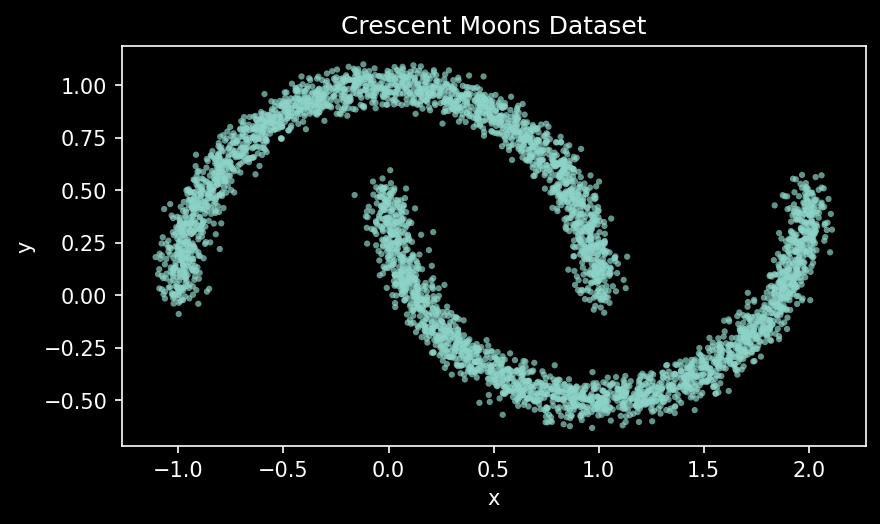

In [ ]:
# Make crescent moons dataset
from sklearn.datasets import make_moons

n_dim = 2
n_train = 1024*4
y_train,_ = make_moons(n_samples=n_train, noise=0.05, random_state=42)
y_train = y_train.astype('f4') # Ensure 32-bit floats for TensorFlow

plt.scatter(y_train[:, 0], y_train[:, 1], s=9, alpha=0.7, edgecolors='none')
plt.title("Crescent Moons Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.gca().set_aspect('equal')
plt.show()

In [ ]:
# Instantiate the model
transformation_model = RealNVP(
    n_affine_layers=8,
    n_hidden=3,
    hidden_size=32,
    n_dim=2,
    n_condition=1
)

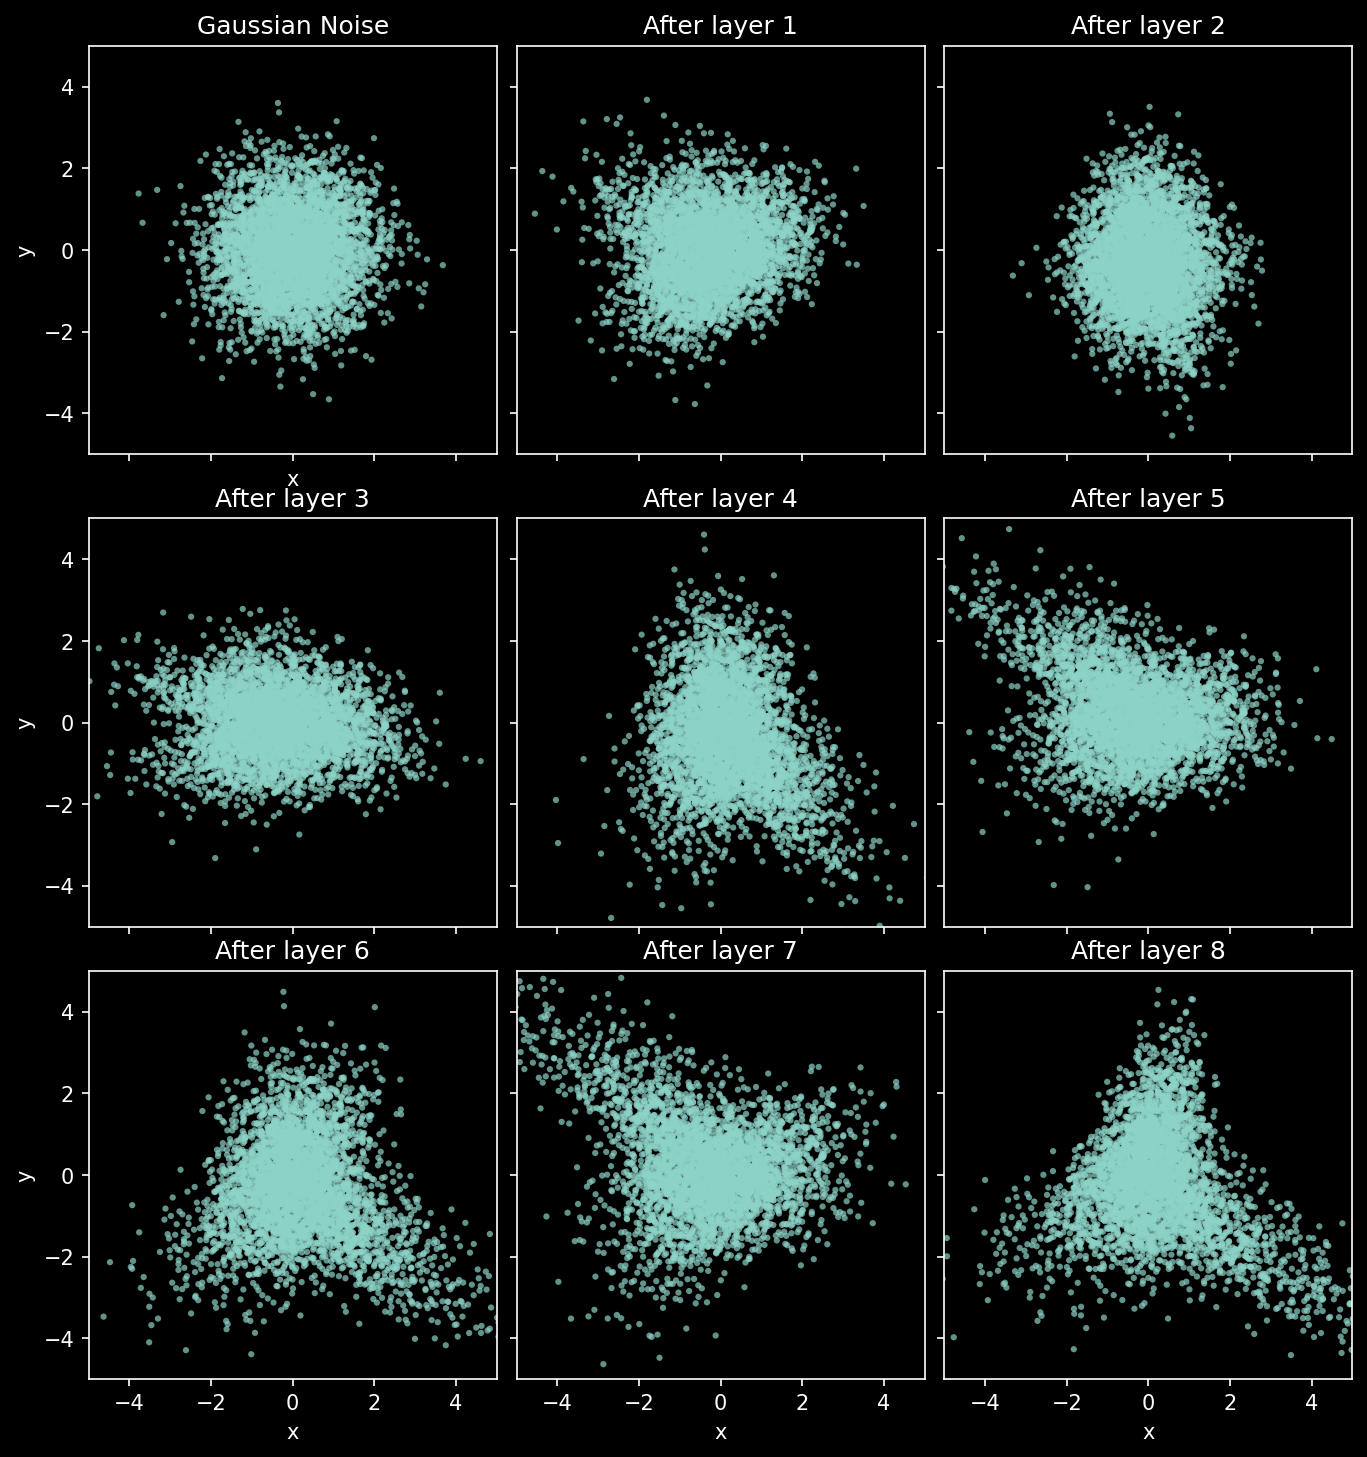

In [ ]:
x = tf.random.normal((n_train, n_dim))
intermediate_results = transformation_model.forward(x, return_intermediate=True)

n_panels = len(intermediate_results) + 1

# Reshape to be roughly square
n_col = int(np.ceil(np.sqrt(n_panels)))
n_row = int(np.ceil(n_panels / n_col))

fig,ax_arr = plt.subplots(
    n_row, n_col, figsize=(3*n_col, 3*n_row+0.5),
    sharex=True, sharey=True,
    layout='constrained',
    subplot_kw=dict(aspect='equal')
)

kw = dict(s=9, edgecolors='none', alpha=0.7)

ax = ax_arr.flat[0]
ax.scatter(x[:, 0], x[:, 1], **kw)
ax.set_title("Gaussian Noise")
ax.set_xlabel("x")
ax.set_ylabel("y")

for i,((y,_), ax) in enumerate(zip(intermediate_results,ax_arr.flat[1:])):
    ax.scatter(y[:, 0], y[:, 1], **kw)
    ax.set_title(f"After layer {i+1}")
    if ax.get_subplotspec().is_last_row():
        ax.set_xlabel("x")
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel("y")

for ax in ax_arr.flat:
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)

plt.show()

In [ ]:
# Train the model on the crescent moons dataset

opt = tf.optimizers.Adam(learning_rate=1e-4)
n_epochs = 1024*2

def compute_loss(y):
    # Inverse pass to get x and log det(J)
    x, log_det_jacobian = transformation_model.inverse(y)
    # Compute log p(x) under the base distribution (standard normal)
    log_p_x = -0.5 * tf.reduce_sum(x**2, axis=-1) # Ignore normalization constant
    # Compute log p(y) using the change of variables formula
    log_p_y = log_p_x + log_det_jacobian
    # We want to maximize log p(y), which is equivalent to minimizing -log p(y)
    return -tf.reduce_mean(log_p_y)

@tf.function
def training_step():
    # Calculate the loss
    with tf.GradientTape() as tape:
        loss = compute_loss(y_train)

    # Compute gradients and update model parameters
    grads = tape.gradient(loss, transformation_model.trainable_variables)
    opt.apply_gradients(zip(grads, transformation_model.trainable_variables))

    return loss

iter = tqdm(range(n_epochs), desc="Training")

for epoch in iter:
    loss = training_step()

    # Progress bar update
    iter.set_postfix({"loss": loss.numpy()})

Training:   0%|          | 0/2048 [00:00<?, ?it/s]

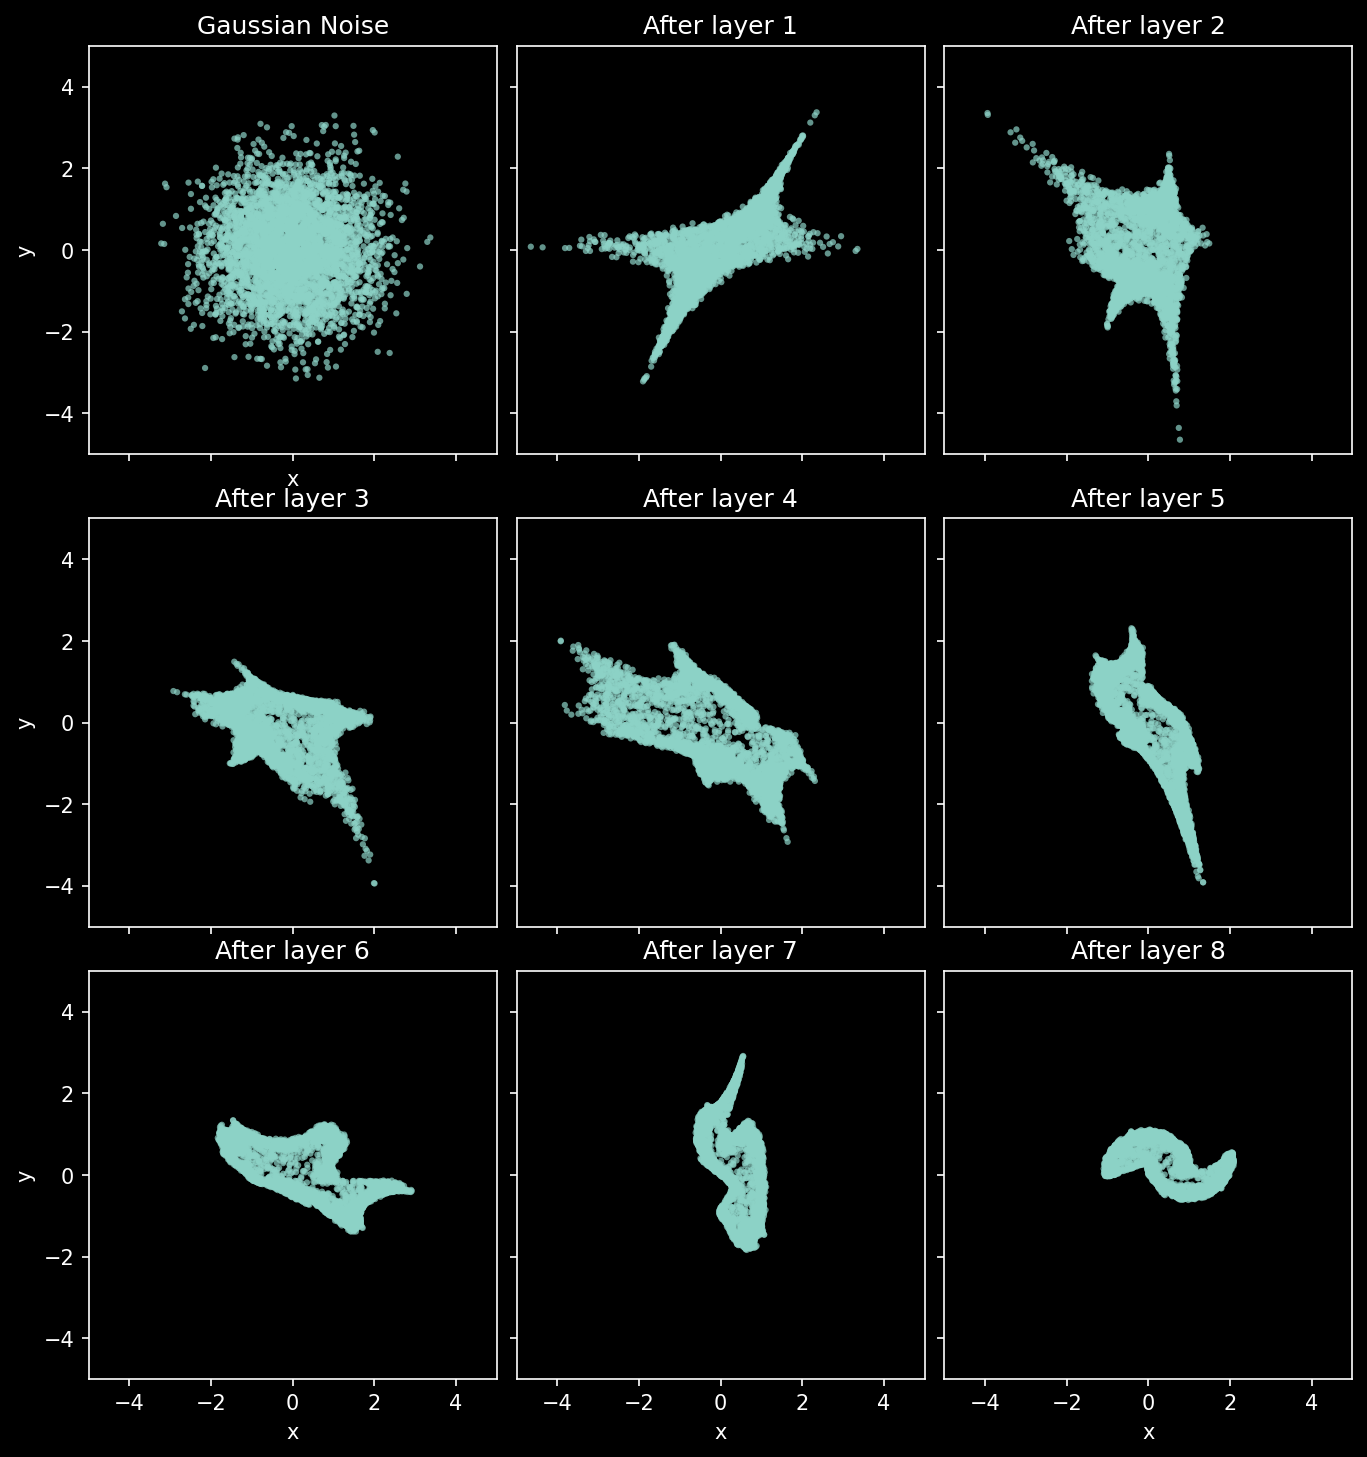

In [ ]:
x = tf.random.normal((n_train, n_dim))
intermediate_results = transformation_model.forward(x, return_intermediate=True)

n_panels = len(intermediate_results) + 1

# Reshape to be roughly square
n_col = int(np.ceil(np.sqrt(n_panels)))
n_row = int(np.ceil(n_panels / n_col))

fig,ax_arr = plt.subplots(
    n_row, n_col, figsize=(3*n_col, 3*n_row+0.5),
    sharex=True, sharey=True,
    layout='constrained',
    subplot_kw=dict(aspect='equal')
)

kw = dict(s=9, edgecolors='none', alpha=0.7)

ax = ax_arr.flat[0]
ax.scatter(x[:, 0], x[:, 1], **kw)
ax.set_title("Gaussian Noise")
ax.set_xlabel("x")
ax.set_ylabel("y")

for i,((y,_), ax) in enumerate(zip(intermediate_results,ax_arr.flat[1:])):
    ax.scatter(y[:, 0], y[:, 1], **kw)
    ax.set_title(f"After layer {i+1}")
    if ax.get_subplotspec().is_last_row():
        ax.set_xlabel("x")
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel("y")

for ax in ax_arr.flat:
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)

plt.show()

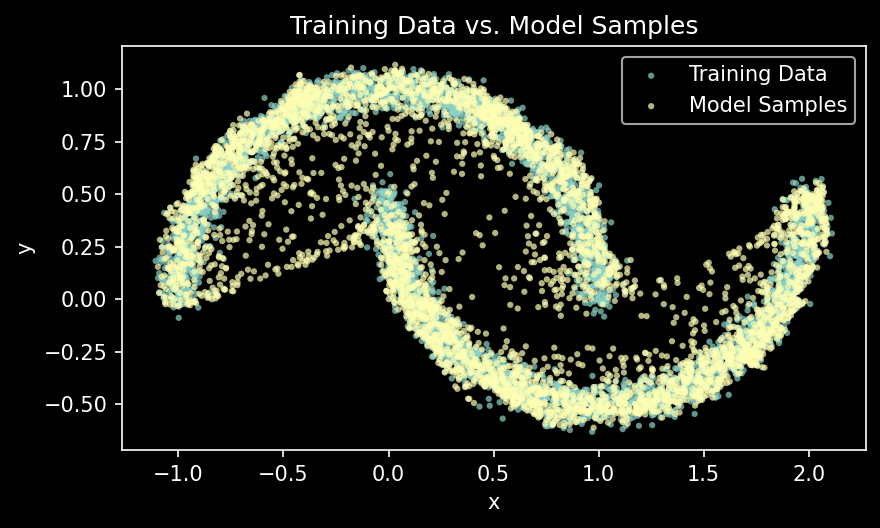

In [ ]:
# Plot training data vs. samples from model

kw = dict(s=9, alpha=0.7, edgecolors='none')
plt.scatter(y_train[:, 0], y_train[:, 1], label='Training Data', **kw)
plt.scatter(
    intermediate_results[-1][0][:, 0],
    intermediate_results[-1][0][:, 1],
    label='Model Samples', **kw
)
plt.title("Training Data vs. Model Samples")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.gca().set_aspect('equal')
plt.show()

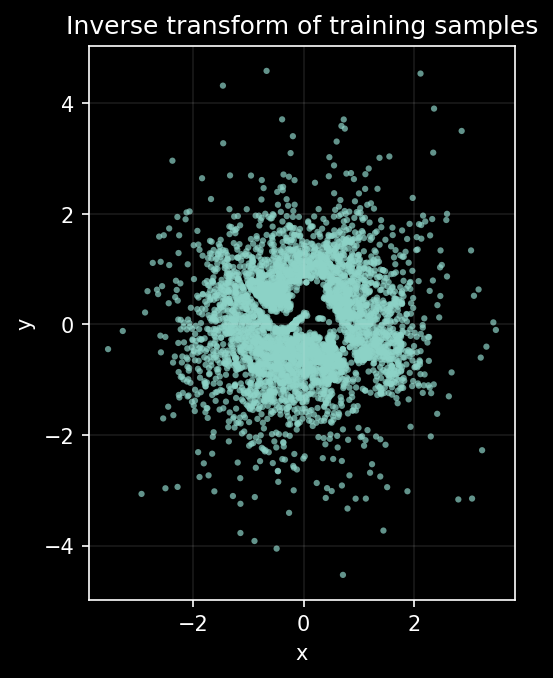

In [ ]:
# Plot training samples transformed back to Gaussian space
x,_ = transformation_model.inverse(y_train)
plt.scatter(x[:,0], x[:,1], **kw)
plt.title("Inverse transform of training samples")
plt.xlabel("x")
plt.ylabel("y")
plt.gca().set_aspect('equal')
plt.grid(True, which='major', alpha=0.1)
plt.show()